## Step 1 — Load extracted data & run FinBERT

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

TARGET_STOCKS = [
    # Tech (large cap)
    'AAPL', 'AMZN', 'MSFT', 'TSLA', 'GOOGL', 'NVDA', 'NFLX',
    # Finance
    'JPM', 'BAC', 'GS', 'MS', 'WFC',
    # Healthcare/Pharma
    'PFE', 'JNJ', 'ABT','MRK', 'ABBV', 'GILD',
    # Energy
    'XOM', 'CVX', 'COP', 'SLB',
    # Retail/Consumer
    'WMT', 'TGT', 'NKE', 'COST', 'MCD',
    # EV/Clean Energy
    'NIO', 'F', 'ENPH',
    # Semiconductor
    'AMD', 'INTC', 'QCOM', 'AVGO',
    # Aerospace/Defense
    'BA', 'LMT', 'RTX',
    # Real Estate
    'AMT', 'PLD', 'PSA', 'DLR',
]

OUTPUT_FILE   = "all_stocks_data.csv"

In [2]:
from transformers import pipeline as hf_pipeline

df = pd.read_csv(OUTPUT_FILE)
df = df[df['Stock_symbol'].isin(TARGET_STOCKS)]  # removes GM and any other unwanted stocks
df['Date'] = pd.to_datetime(df['Date'])
df.dropna(subset=['Article_title'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Loaded {len(df):,} rows")
print(df['Stock_symbol'].value_counts())

Loaded 247,956 rows
Stock_symbol
GILD     12376
NVDA     11862
WFC      11301
INTC     11157
MRK      10774
TSLA     10587
MS        9458
AAPL      9338
AMD       9209
QCOM      8954
MSFT      8737
GS        8730
CVX       8688
WMT       8686
AMT       7912
SLB       7394
XOM       7346
NKE       7129
COP       6929
COST      6781
ABBV      6451
BA        6075
AMZN      5060
NIO       4883
AVGO      4156
ABT       4055
PSA       3575
TGT       3155
NFLX      3028
JNJ       2928
JPM       2883
ENPH      2788
LMT       2242
MCD       2236
DLR       2035
F         1885
PFE       1821
BAC       1811
PLD       1787
GOOGL     1754
Name: count, dtype: int64


In [3]:
df = pd.read_csv(OUTPUT_FILE)
df = df[df['Stock_symbol'].isin(TARGET_STOCKS)]  # removes GM and any unlisted stocks
df['Date'] = pd.to_datetime(df['Date'])

# df.dropna(subset=['Article_title'], inplace=True)
# df.reset_index(drop=True, inplace=True)

# print(f"Loaded {len(df):,} rows")
# print(df['Stock_symbol'].value_counts())


# Use LSA summary if available, fall back to title if missing
df['text_for_sentiment'] = df['Lsa_summary'].fillna(df['Article_title'])
# df['text_for_sentiment'] = (df['Luhn_summary']
#                              .fillna(df['Textrank_summary'])
#                              .fillna(df['Article_title']))

# Drop rows where both are missing
df.dropna(subset=['text_for_sentiment'], inplace=True)


# lsa summary
print(f"\nUsing LSA summary: {df['Lsa_summary'].notna().sum():,} rows")
print(f"Falling back to title: {df['Lsa_summary'].isna().sum():,} rows")
# luhn summary
# print(f"\nUsing Luhn summary:     {df['Luhn_summary'].notna().sum():,} rows")
# print(f"Falling back to Textrank: {(df['Luhn_summary'].isna() & df['Textrank_summary'].notna()).sum():,} rows")
# print(f"Falling back to title:    {(df['Luhn_summary'].isna() & df['Textrank_summary'].isna()).sum():,} rows")


Using LSA summary: 184,583 rows
Falling back to title: 63,373 rows


In [4]:
# device=0 uses GPU; set device=-1 for CPU only
classifier = hf_pipeline(
    "sentiment-analysis",
    model="ProsusAI/finbert",
    device=0,
    batch_size=16,
    truncation=True,
    max_length=512
)

def get_sentiment(texts):
    results = classifier(texts)
    return [(r['label'], round(r['score'], 4)) for r in results]

print("Running FinBERT inference...")
# this is using summary
outputs = get_sentiment(df['text_for_sentiment'].tolist())
# outputs = get_sentiment(df['Article_title'].tolist())
df['sentiment_label'] = [o[0] for o in outputs]
df['sentiment_score']  = [o[1] for o in outputs]

print(df[['Stock_symbol', 'Article_title', 'sentiment_label', 'sentiment_score']].head(10))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Running FinBERT inference...
  Stock_symbol                                      Article_title  \
0         AAPL  My 6 Largest Portfolio Holdings Heading Into 2...   
1         AAPL  Brokers Suggest Investing in Apple (AAPL): Rea...   
2         AAPL                      Company News for Dec 19, 2023   
3         AAPL  NVIDIA (NVDA) Up 243% YTD: Will It Carry Momen...   
4         AAPL  Pre-Market Most Active for Dec 19, 2023 : BMY,...   
5         AAPL  3 Artificial Intelligence (AI) Stocks for 2024...   
6         AAPL                   AAPL Quantitative Stock Analysis   
7         AAPL  Should Vanguard S&P 500 ETF (VOO) Be on Your I...   
8         AAPL  Is FlexShares Quality Dividend ETF (QDF) a Str...   
9         AAPL  Is FlexShares STOXX US ESG Select Index Fund (...   

  sentiment_label  sentiment_score  
0        positive           0.5895  
1         neutral           0.8987  
2        negative           0.9726  
3         neutral           0.9389  
4         neutral         

## Step 2 — Daily sentiment aggregation

**IMPROVEMENT (quick win — data):** The original code only aggregated `avg_sentiment`
and `article_count`. We now also compute:
- `avg_confidence`: mean FinBERT confidence score. A 'positive' at 0.95 confidence
  is very different from 0.51 — this signal is lost when only using the label.
- `sentiment_std`: std of sentiment within the day. High std = conflicting news coverage,
  which is itself a signal of uncertainty.
- `positive_ratio` / `negative_ratio`: fraction of articles per class, capturing
  the mix better than the average alone.

In [17]:
label_map = {'positive': 1, 'neutral': 0, 'negative': -1}
df['sentiment_numeric'] = df['sentiment_label'].map(label_map)

daily_sentiment = (
    df.groupby(['Stock_symbol', 'Date'])
      .agg(
          avg_sentiment  = ('sentiment_numeric', 'mean'),
          sentiment_std  = ('sentiment_numeric', 'std'),
          avg_confidence = ('sentiment_score',   'mean'),
          article_count  = ('Article_title',      'count'),
          positive_ratio = ('sentiment_numeric',  lambda x: (x == 1).mean()),
          negative_ratio = ('sentiment_numeric',  lambda x: (x == -1).mean())
      )
      .reset_index()
)

# sentiment_std is NaN when only 1 article that day — fill with 0
# daily_sentiment['sentiment_std'].fillna(0, inplace=True)
daily_sentiment['sentiment_std'] = daily_sentiment['sentiment_std'].fillna(0)

print(daily_sentiment.head(20))
print(f"\nDate range: {daily_sentiment['Date'].min()} — {daily_sentiment['Date'].max()}")

   Stock_symbol                      Date  avg_sentiment  sentiment_std  \
0          AAPL 2020-03-09 00:00:00+00:00      -0.333333       0.577350   
1          AAPL 2020-03-10 00:00:00+00:00      -0.375000       0.517549   
2          AAPL 2020-03-11 00:00:00+00:00      -0.214286       0.801784   
3          AAPL 2020-03-12 00:00:00+00:00      -0.200000       0.836660   
4          AAPL 2020-03-13 00:00:00+00:00       0.181818       0.750757   
5          AAPL 2020-03-14 00:00:00+00:00      -0.500000       0.707107   
6          AAPL 2020-03-15 00:00:00+00:00      -0.250000       0.957427   
7          AAPL 2020-03-16 00:00:00+00:00      -0.545455       0.522233   
8          AAPL 2020-03-17 00:00:00+00:00      -0.166667       0.834847   
9          AAPL 2020-03-18 00:00:00+00:00       0.000000       0.816497   
10         AAPL 2020-03-19 00:00:00+00:00       0.000000       0.000000   
11         AAPL 2020-03-20 00:00:00+00:00       0.000000       1.414214   
12         AAPL 2020-03-2

### Step 2b — Sentiment lag & momentum features

**IMPROVEMENT (medium effort — data):** Markets sometimes react with a delay.
Adding t-1 and t-2 sentiment lags lets the model learn delayed reactions.
`sentiment_momentum` (today minus yesterday) captures whether sentiment is
improving or deteriorating — often more predictive than the raw level.

In [18]:
daily_sentiment.sort_values(['Stock_symbol', 'Date'], inplace=True)

for ticker in TARGET_STOCKS:
    mask = daily_sentiment['Stock_symbol'] == ticker
    daily_sentiment.loc[mask, 'sentiment_lag1'] = \
        daily_sentiment.loc[mask, 'avg_sentiment'].shift(1)
    daily_sentiment.loc[mask, 'sentiment_lag2'] = \
        daily_sentiment.loc[mask, 'avg_sentiment'].shift(2)

daily_sentiment['sentiment_momentum'] = (
    daily_sentiment['avg_sentiment'] - daily_sentiment['sentiment_lag1']
)

print(daily_sentiment[['Stock_symbol', 'Date', 'avg_sentiment',
                         'sentiment_lag1', 'sentiment_lag2',
                         'sentiment_momentum']].head(10))

  Stock_symbol                      Date  avg_sentiment  sentiment_lag1  \
0         AAPL 2020-03-09 00:00:00+00:00      -0.333333             NaN   
1         AAPL 2020-03-10 00:00:00+00:00      -0.375000       -0.333333   
2         AAPL 2020-03-11 00:00:00+00:00      -0.214286       -0.375000   
3         AAPL 2020-03-12 00:00:00+00:00      -0.200000       -0.214286   
4         AAPL 2020-03-13 00:00:00+00:00       0.181818       -0.200000   
5         AAPL 2020-03-14 00:00:00+00:00      -0.500000        0.181818   
6         AAPL 2020-03-15 00:00:00+00:00      -0.250000       -0.500000   
7         AAPL 2020-03-16 00:00:00+00:00      -0.545455       -0.250000   
8         AAPL 2020-03-17 00:00:00+00:00      -0.166667       -0.545455   
9         AAPL 2020-03-18 00:00:00+00:00       0.000000       -0.166667   

   sentiment_lag2  sentiment_momentum  
0             NaN                 NaN  
1             NaN           -0.041667  
2       -0.333333            0.160714  
3       -0.375

## Step 3 — Load price data & compute returns

In [19]:
price_folder = r'full_history\full_history'
price_chunks = []

for ticker in TARGET_STOCKS:
    file_path = os.path.join(price_folder, f"{ticker}.csv")
    if not os.path.exists(file_path):
        print(f"WARNING: {file_path} not found, skipping {ticker}")
        continue

    df_p = pd.read_csv(file_path)
    df_p.columns = [c.lower() for c in df_p.columns]
    df_p['Date'] = pd.to_datetime(df_p['date']).dt.tz_localize(None)
    df_p['Stock_symbol'] = ticker
    df_p.sort_values('Date', inplace=True)

    df_p['return_next_day'] = df_p['adj close'].pct_change().shift(-1)
    df_p['direction']       = (df_p['return_next_day'] > 0).astype(int)
    df_p.dropna(subset=['return_next_day'], inplace=True)

    price_chunks.append(
        df_p[['Stock_symbol', 'Date', 'adj close', 'return_next_day', 'direction']]
    )
    print(f"{ticker}: {len(df_p):,} trading days loaded")

price_df = pd.concat(price_chunks, ignore_index=True)
print(f"\nTotal price rows: {len(price_df):,}")

AAPL: 10,851 trading days loaded
AMZN: 6,699 trading days loaded
MSFT: 9,525 trading days loaded
TSLA: 3,398 trading days loaded
GOOGL: 3,931 trading days loaded
NVDA: 6,274 trading days loaded
NFLX: 4,550 trading days loaded
JPM: 11,039 trading days loaded
BAC: 11,948 trading days loaded
GS: 6,204 trading days loaded
MS: 7,770 trading days loaded


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8176\3926479964.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_p['return_next_day'] = df_p['adj close'].pct_change().shift(-1)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_8176\3926479964.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_p['return_next_day'] = df_p['adj close'].pct_change().shift(-1)


WFC: 13,005 trading days loaded
PFE: 13,005 trading days loaded
JNJ: 15,604 trading days loaded
ABT: 11,039 trading days loaded
MRK: 13,617 trading days loaded
ABBV: 2,766 trading days loaded
GILD: 8,043 trading days loaded
XOM: 13,617 trading days loaded
CVX: 15,604 trading days loaded
COP: 10,586 trading days loaded
SLB: 1,384 trading days loaded
WMT: 12,945 trading days loaded
TGT: 12,825 trading days loaded
NKE: 10,860 trading days loaded
COST: 9,444 trading days loaded
MCD: 13,591 trading days loaded
NIO: 1,332 trading days loaded
F: 13,005 trading days loaded
ENPH: 2,955 trading days loaded
AMD: 11,039 trading days loaded


C:\Users\ASUS\AppData\Local\Temp\ipykernel_8176\3926479964.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_p['return_next_day'] = df_p['adj close'].pct_change().shift(-1)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_8176\3926479964.py:16: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_p['return_next_day'] = df_p['adj close'].pct_change().shift(-1)


INTC: 11,039 trading days loaded
QCOM: 8,069 trading days loaded
AVGO: 3,623 trading days loaded
BA: 15,604 trading days loaded
LMT: 11,849 trading days loaded
RTX: 12,728 trading days loaded
AMT: 6,501 trading days loaded
PLD: 6,566 trading days loaded
PSA: 10,868 trading days loaded
DLR: 3,936 trading days loaded

Total price rows: 379,238


### Step 3b — Add price-based features

**IMPROVEMENT (medium effort — data):** Pure sentiment models are weak in isolation.
Combining sentiment with price momentum consistently improves performance in literature.
We add:
- `prev_return`: yesterday's return (short-term momentum signal)
- `volatility_5d`: 5-day rolling return std (current market regime)
- `volatility_20d`: 20-day rolling return std (longer-term regime)

Note: all rolling features use `.shift(1)` so they only use data available
at prediction time — no lookahead leakage.

In [20]:
price_df.sort_values(['Stock_symbol', 'Date'], inplace=True)

for ticker in TARGET_STOCKS:
    mask = price_df['Stock_symbol'] == ticker
    ret  = price_df.loc[mask, 'return_next_day']
    price_df.loc[mask, 'prev_return']    = ret.shift(1)
    price_df.loc[mask, 'volatility_5d']  = ret.shift(1).rolling(5).std()
    price_df.loc[mask, 'volatility_20d'] = ret.shift(1).rolling(20).std()

print(price_df[['Stock_symbol', 'Date', 'return_next_day',
                 'prev_return', 'volatility_5d', 'volatility_20d']].head(10))

  Stock_symbol       Date  return_next_day  prev_return  volatility_5d  \
0         AAPL 1980-12-12        -0.052174          NaN            NaN   
1         AAPL 1980-12-15        -0.073395    -0.052174            NaN   
2         AAPL 1980-12-16         0.024752    -0.073395            NaN   
3         AAPL 1980-12-17         0.028986     0.024752            NaN   
4         AAPL 1980-12-18         0.061033     0.028986            NaN   
5         AAPL 1980-12-19         0.048673     0.061033       0.057583   
6         AAPL 1980-12-22         0.042194     0.048673       0.053179   
7         AAPL 1980-12-23         0.052631     0.042194       0.014747   
8         AAPL 1980-12-24         0.092308     0.052631       0.012027   
9         AAPL 1980-12-26         0.014084     0.092308       0.019638   

   volatility_20d  
0             NaN  
1             NaN  
2             NaN  
3             NaN  
4             NaN  
5             NaN  
6             NaN  
7             NaN  
8    

### Step 3c — Merge sentiment and price

In [21]:
def strip_tz(series):
    s = pd.to_datetime(series)
    if s.dt.tz is not None:
        return s.dt.tz_convert(None)
    return s

# Strip timezone from both sides to avoid merge errors
daily_sentiment['Date'] = strip_tz(daily_sentiment['Date'])
price_df['Date']        = strip_tz(price_df['Date'])

merged = pd.merge(
    daily_sentiment,
    price_df[['Stock_symbol', 'Date', 'return_next_day', 'direction',
               'prev_return', 'volatility_5d', 'volatility_20d']],
    on=['Stock_symbol', 'Date'],
    how='inner'
)
# Drop rows where lag/volatility features are NaN (first few rows per ticker)
merged.dropna(inplace=True)
merged.reset_index(drop=True, inplace=True)

print(f"Merged dataset: {len(merged):,} rows")
print(merged.head())

Merged dataset: 56,144 rows
  Stock_symbol       Date  avg_sentiment  sentiment_std  avg_confidence  \
0         AAPL 2020-03-11      -0.214286       0.801784        0.830993   
1         AAPL 2020-03-12      -0.200000       0.836660        0.805480   
2         AAPL 2020-03-13       0.181818       0.750757        0.763345   
3         AAPL 2020-03-16      -0.545455       0.522233        0.784273   
4         AAPL 2020-03-17      -0.166667       0.834847        0.829667   

   article_count  positive_ratio  negative_ratio  sentiment_lag1  \
0             14        0.214286        0.428571       -0.375000   
1              5        0.200000        0.400000       -0.214286   
2             11        0.363636        0.181818       -0.200000   
3             11        0.000000        0.545455       -0.250000   
4             12        0.250000        0.416667       -0.545455   

   sentiment_lag2  sentiment_momentum  return_next_day  direction  \
0       -0.333333            0.160714      

## Step 4 — Model training

**IMPROVEMENT (quick win — model):** Three changes from the original:

1. **Expanded feature set**: now includes confidence, std, ratios, lags, momentum,
   and price-based features instead of just `avg_sentiment` + `article_count`.

2. **`class_weight='balanced'` on Logistic Regression**: fixes the original problem
   where LR predicted 'up' almost every time (recall=0.07 for down days).
   This tells sklearn to weight the minority class higher during training.

3. **TimeSeriesSplit instead of random train/test split**: random shuffling leaks
   future data into training, which is a methodological flaw for time series.
   TimeSeriesSplit always trains on past and tests on future — how a real
   trading model would be evaluated.

In [22]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from xgboost import XGBClassifier

FEATURES = [
    'avg_sentiment', 'sentiment_std', 'avg_confidence',
    'article_count', 'positive_ratio', 'negative_ratio',
    'sentiment_lag1', 'sentiment_lag2', 'sentiment_momentum',
    'prev_return', 'volatility_5d', 'volatility_20d'
]
TARGET = 'direction'

# Sort by date so TimeSeriesSplit works correctly
merged.sort_values('Date', inplace=True)
X = merged[FEATURES]
y = merged[TARGET]

# 5 folds: each trains on past, tests on future
tscv = TimeSeriesSplit(n_splits=5)

lr_scores  = []
xgb_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Logistic Regression with class_weight='balanced'
    lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=500)
    lr.fit(X_train, y_train)
    lr_preds = lr.predict(X_test)
    lr_scores.append(accuracy_score(y_test, lr_preds))

    # XGBoost
    xgb = XGBClassifier(n_estimators=100, max_depth=4,
                         eval_metric='logloss', random_state=42, verbosity=0)
    xgb.fit(X_train, y_train)
    xgb_preds = xgb.predict(X_test)
    xgb_scores.append(accuracy_score(y_test, xgb_preds))

    print(f"--- Fold {fold+1} (test size: {len(y_test)}) ---")
    print(f"  LR accuracy:  {lr_scores[-1]:.2%}")
    print(f"  XGB accuracy: {xgb_scores[-1]:.2%}")

print(f"\n=== Mean accuracy across all folds ===")
print(f"  Logistic Regression: {np.mean(lr_scores):.2%} (+/- {np.std(lr_scores):.2%})")
print(f"  XGBoost:             {np.mean(xgb_scores):.2%} (+/- {np.std(xgb_scores):.2%})")

--- Fold 1 (test size: 9357) ---
  LR accuracy:  50.53%
  XGB accuracy: 49.72%
--- Fold 2 (test size: 9357) ---
  LR accuracy:  50.79%
  XGB accuracy: 50.53%
--- Fold 3 (test size: 9357) ---
  LR accuracy:  50.25%
  XGB accuracy: 49.58%
--- Fold 4 (test size: 9357) ---
  LR accuracy:  51.07%
  XGB accuracy: 51.22%
--- Fold 5 (test size: 9357) ---
  LR accuracy:  48.72%
  XGB accuracy: 50.22%

=== Mean accuracy across all folds ===
  Logistic Regression: 50.27% (+/- 0.82%)
  XGBoost:             50.25% (+/- 0.59%)


### Step 4b — Full report on last fold + feature importance

We print the full classification report for the last fold (most recent test period),
and plot XGBoost feature importances to understand which features drove predictions.
This is useful for discussing which signals matter most in the final report.

=== Logistic Regression — last fold ===
              precision    recall  f1-score   support

           0       0.47      0.56      0.51      4521
           1       0.50      0.42      0.46      4836

    accuracy                           0.49      9357
   macro avg       0.49      0.49      0.49      9357
weighted avg       0.49      0.49      0.49      9357

=== XGBoost — last fold ===
              precision    recall  f1-score   support

           0       0.48      0.39      0.43      4521
           1       0.52      0.60      0.56      4836

    accuracy                           0.50      9357
   macro avg       0.50      0.50      0.49      9357
weighted avg       0.50      0.50      0.50      9357



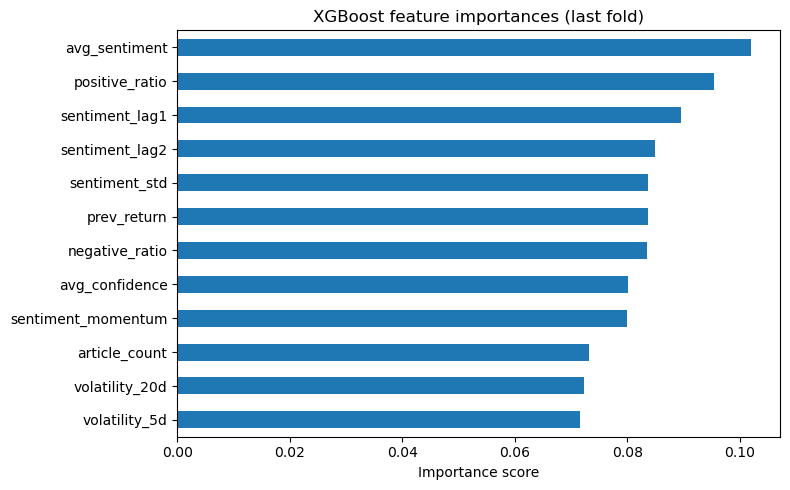

In [23]:
print("=== Logistic Regression — last fold ===")
print(classification_report(y_test, lr_preds))

print("=== XGBoost — last fold ===")
print(classification_report(y_test, xgb_preds))

# Feature importances
importances = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(8, 5))
plt.title('XGBoost feature importances (last fold)')
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

### Step 4c — Per-ticker models

**IMPROVEMENT (medium effort — model):** AAPL and AMZN have very different
volatility profiles (as shown in the proposal Table I — AMZN std=22.16, AAPL std=5.12).
A pooled model treats both identically, which dilutes signal.
Training one XGBoost per ticker lets each model learn ticker-specific dynamics.
We use an 80/20 chronological split here for quick comparison.

In [24]:
for ticker in TARGET_STOCKS:
    df_t = merged[merged['Stock_symbol'] == ticker].sort_values('Date')
    if len(df_t) < 30:
        print(f"{ticker}: not enough data, skipping")
        continue

    split  = int(len(df_t) * 0.8)
    X_tr   = df_t[FEATURES].iloc[:split]
    X_te   = df_t[FEATURES].iloc[split:]
    y_tr   = df_t[TARGET].iloc[:split]
    y_te   = df_t[TARGET].iloc[split:]

    xgb_t  = XGBClassifier(n_estimators=100, max_depth=4,
                            eval_metric='logloss', random_state=42, verbosity=0)
    xgb_t.fit(X_tr, y_tr)
    preds  = xgb_t.predict(X_te)

    print(f"\n=== {ticker} — per-ticker XGBoost ===")
    print(f"  Test rows: {len(y_te)} | Accuracy: {accuracy_score(y_te, preds):.2%}")
    print(classification_report(y_te, preds))


=== AAPL — per-ticker XGBoost ===
  Test rows: 89 | Accuracy: 56.18%
              precision    recall  f1-score   support

           0       0.47      0.58      0.52        36
           1       0.66      0.55      0.60        53

    accuracy                           0.56        89
   macro avg       0.56      0.57      0.56        89
weighted avg       0.58      0.56      0.57        89


=== AMZN — per-ticker XGBoost ===
  Test rows: 44 | Accuracy: 59.09%
              precision    recall  f1-score   support

           0       0.50      0.44      0.47        18
           1       0.64      0.69      0.67        26

    accuracy                           0.59        44
   macro avg       0.57      0.57      0.57        44
weighted avg       0.58      0.59      0.59        44


=== MSFT — per-ticker XGBoost ===
  Test rows: 83 | Accuracy: 50.60%
              precision    recall  f1-score   support

           0       0.37      0.41      0.39        32
           1       0.60    

In [30]:
# Get ALL per-ticker results in one pass for the complete table
ticker_results = []
for ticker in TARGET_STOCKS:
    df_t = merged[merged['Stock_symbol'] == ticker].sort_values('Date')
    if len(df_t) < 30:
        continue
    split = int(len(df_t) * 0.8)
    xgb_t = XGBClassifier(n_estimators=100, max_depth=4,
                           eval_metric='logloss', random_state=42, verbosity=0)
    xgb_t.fit(df_t[FEATURES].iloc[:split], df_t[TARGET].iloc[:split])
    acc = accuracy_score(df_t[TARGET].iloc[split:], 
                         xgb_t.predict(df_t[FEATURES].iloc[split:]))
    ticker_results.append({'Ticker': ticker, 'Accuracy': f"{acc:.2%}", 
                           'Test_rows': len(df_t) - split})

df_all_tickers = pd.DataFrame(ticker_results)
df_all_tickers.to_csv(os.path.join(results_folder, 'table_all_tickers.csv'), index=False)
print(df_all_tickers.to_string(index=False))

Ticker Accuracy  Test_rows
  AAPL   56.18%         89
  AMZN   59.09%         44
  MSFT   50.60%         83
  TSLA   51.56%        128
 GOOGL   57.33%         75
  NVDA   49.85%        341
  NFLX   48.39%        155
   JPM   55.95%         84
   BAC   48.19%        166
    GS   52.29%        371
    MS   45.60%        546
   WFC   46.22%        476
   PFE   45.21%        146
   JNJ   49.80%        251
   ABT   52.81%        356
   MRK   49.05%        581
  ABBV   51.90%        422
  GILD   48.43%        543
   XOM   51.04%        241
   CVX   45.20%        354
   COP   51.25%        521
   SLB   42.86%        238
   WMT   48.21%        251
   TGT   52.63%        152
   NKE   53.13%        463
  COST   47.82%        458
   MCD   49.43%        176
   NIO   50.65%        231
     F   44.93%         69
  ENPH   54.31%        232
   AMD   49.70%        336
  INTC   50.85%        295
  QCOM   50.29%        515
  AVGO   52.47%        223
    BA   55.19%        183
   LMT   51.10%        227
 

### Step 4d — High-confidence threshold strategy

**IMPROVEMENT (medium effort — model):** Instead of predicting every day,
only act on days where avg_sentiment is extreme (above THRESHOLD or below -THRESHOLD).
Precision on high-sentiment days is often better than overall accuracy, and this
reflects how a real quant signal would be used — only trade when conviction is high.
Try adjusting THRESHOLD to see the precision vs coverage tradeoff.

In [25]:
THRESHOLD = 0.3   # raise this for higher precision, lower for more coverage

# Train a final pooled model on 80% of data chronologically
merged_sorted = merged.sort_values('Date')
split         = int(len(merged_sorted) * 0.8)
X_full_tr     = merged_sorted[FEATURES].iloc[:split]
X_full_te     = merged_sorted[FEATURES].iloc[split:]
y_full_tr     = merged_sorted[TARGET].iloc[:split]
y_full_te     = merged_sorted[TARGET].iloc[split:]

xgb_full = XGBClassifier(n_estimators=100, max_depth=4,
                          eval_metric='logloss', random_state=42, verbosity=0)
xgb_full.fit(X_full_tr, y_full_tr)

test_df              = merged_sorted.iloc[split:].copy()
test_df['predicted'] = xgb_full.predict(X_full_te)
high_conf            = test_df[test_df['avg_sentiment'].abs() > THRESHOLD]

print(f"All test days:       {len(test_df):>4}  |  Accuracy: {accuracy_score(y_full_te, test_df['predicted']):.2%}")
if len(high_conf) > 0:
    print(f"High-sentiment days: {len(high_conf):>4}  |  Accuracy: {accuracy_score(high_conf[TARGET], high_conf['predicted']):.2%}")
    print(f"Coverage: {len(high_conf)/len(test_df):.1%} of all test days")
else:
    print(f"No days exceed threshold={THRESHOLD}, try lowering it.")

All test days:       11229  |  Accuracy: 50.19%
High-sentiment days: 5495  |  Accuracy: 49.65%
Coverage: 48.9% of all test days


## Step 5 — Evaluation & Black Swan analysis

**IMPROVEMENT (higher effort — evaluation):** The original only checked accuracy
on black swan days. We now also:
- Train a dedicated black swan detector (can sentiment predict WHETHER a day
  will be extreme, not just which direction?)
- Plot sentiment on black swan vs normal days to see if FinBERT captures
  any signal before extreme events — useful discussion for the final report
- Show a confusion matrix for clearer model failure analysis

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Black swan = return beyond ±2 std dev
std  = merged['return_next_day'].std()
mean = merged['return_next_day'].mean()
merged['is_black_swan'] = (merged['return_next_day'].abs() > mean + 2 * std).astype(int)
black_swans = merged[merged['is_black_swan'] == 1]
normal_days = merged[merged['is_black_swan'] == 0]

print(f"Black swan events: {len(black_swans)} / {len(merged)} total days ({len(black_swans)/len(merged):.1%})")

if len(black_swans) > 0:
    bs_preds = xgb_full.predict(black_swans[FEATURES])
    print(f"XGBoost accuracy on black swan days: {accuracy_score(black_swans[TARGET], bs_preds):.2%}")
    print("(Expected to be poor — this is a key finding to report)")

Black swan events: 2522 / 56144 total days (4.5%)
XGBoost accuracy on black swan days: 63.12%
(Expected to be poor — this is a key finding to report)


In [27]:
# --- Dedicated black swan detector ---
# Recreate merged_sorted so it includes the is_black_swan column from Step 6
merged_sorted = merged.sort_values('Date')

y_bs    = merged_sorted['is_black_swan']
y_bs_tr = y_bs.iloc[:split]
y_bs_te = y_bs.iloc[split:]

pos_weight = (y_bs_tr == 0).sum() / max((y_bs_tr == 1).sum(), 1)
xgb_bs = XGBClassifier(n_estimators=100, max_depth=4,
                        scale_pos_weight=pos_weight,
                        eval_metric='logloss', random_state=42, verbosity=0)
xgb_bs.fit(X_full_tr, y_bs_tr)
bs_preds_det = xgb_bs.predict(X_full_te)

print("=== Black Swan Detector ===")
print(classification_report(y_bs_te, bs_preds_det,
                             target_names=['Normal', 'Black Swan']))

=== Black Swan Detector ===
              precision    recall  f1-score   support

      Normal       0.98      0.70      0.81     10606
  Black Swan       0.12      0.71      0.21       623

    accuracy                           0.70     11229
   macro avg       0.55      0.70      0.51     11229
weighted avg       0.93      0.70      0.78     11229



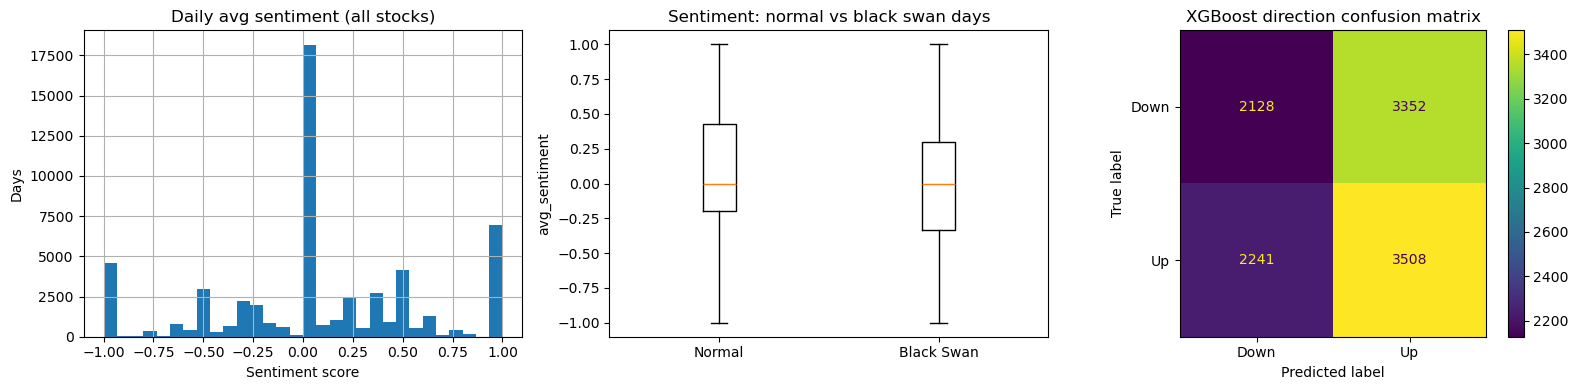

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: overall sentiment distribution
merged['avg_sentiment'].hist(bins=30, ax=axes[0])
axes[0].set_title('Daily avg sentiment (all stocks)')
axes[0].set_xlabel('Sentiment score')
axes[0].set_ylabel('Days')

# Plot 2: sentiment on black swan vs normal days
axes[1].boxplot(
    [normal_days['avg_sentiment'], black_swans['avg_sentiment']],
    tick_labels=['Normal', 'Black Swan']
)
axes[1].set_title('Sentiment: normal vs black swan days')
axes[1].set_ylabel('avg_sentiment')

# Plot 3: confusion matrix for direction prediction
cm = confusion_matrix(y_full_te, xgb_full.predict(X_full_te))
ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up']).plot(ax=axes[2])
axes[2].set_title('XGBoost direction confusion matrix')

plt.tight_layout()
plt.show()

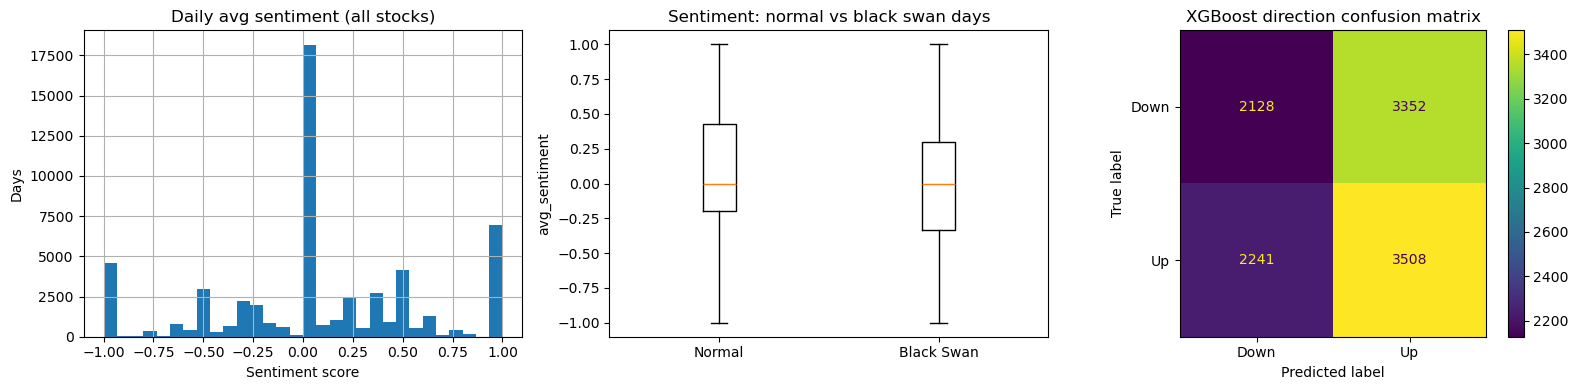

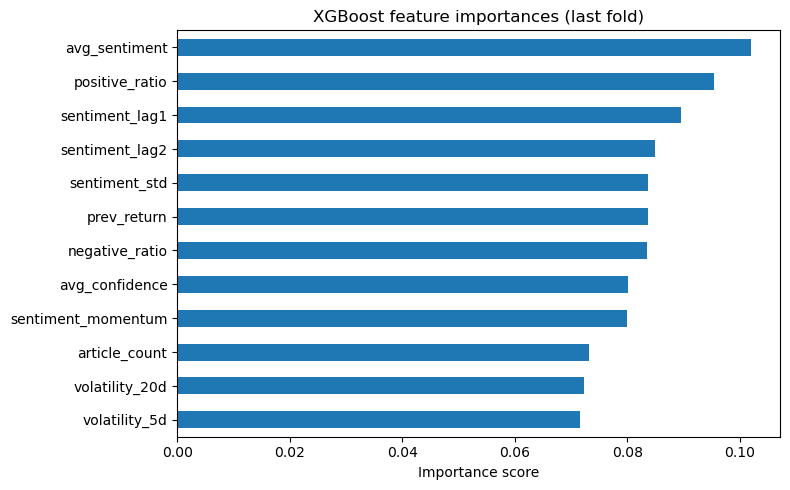

                 Model  Mean_Accuracy  Std_Accuracy
0  Logistic Regression       0.502725      0.008214
1              XGBoost       0.502533      0.005938
    Stock  Article_count
0    GILD          12376
1    NVDA          11862
2     WFC          11301
3    INTC          11157
4     MRK          10774
5    TSLA          10587
6      MS           9458
7    AAPL           9338
8     AMD           9209
9    QCOM           8954
10   MSFT           8737
11     GS           8730
12    CVX           8688
13    WMT           8686
14    AMT           7912
15    SLB           7394
16    XOM           7346
17    NKE           7129
18    COP           6929
19   COST           6781
20   ABBV           6451
21     BA           6075
22   AMZN           5060
23    NIO           4883
24   AVGO           4156
25    ABT           4055
26    PSA           3575
27    TGT           3155
28   NFLX           3028
29    JNJ           2928
30    JPM           2883
31   ENPH           2788
32    LMT          

In [29]:
import os
results_folder = 'report_figures_summary'
os.makedirs(results_folder, exist_ok=True)

# --- Save all 3 plots ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

merged['avg_sentiment'].hist(bins=30, ax=axes[0])
axes[0].set_title('Daily avg sentiment (all stocks)')
axes[0].set_xlabel('Sentiment score')
axes[0].set_ylabel('Days')

axes[1].boxplot(
    [normal_days['avg_sentiment'], black_swans['avg_sentiment']],
    tick_labels=['Normal', 'Black Swan']
)
axes[1].set_title('Sentiment: normal vs black swan days')
axes[1].set_ylabel('avg_sentiment')

cm = confusion_matrix(y_full_te, xgb_full.predict(X_full_te))
ConfusionMatrixDisplay(cm, display_labels=['Down', 'Up']).plot(ax=axes[2])
axes[2].set_title('XGBoost direction confusion matrix')

plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'main_plots.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Save feature importance plot ---
importances = pd.Series(xgb.feature_importances_, index=FEATURES).sort_values(ascending=True)
importances.plot(kind='barh', figsize=(8, 5))
plt.title('XGBoost feature importances (last fold)')
plt.xlabel('Importance score')
plt.tight_layout()
plt.savefig(os.path.join(results_folder, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

# --- Save model summary ---
results_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'Mean_Accuracy': [np.mean(lr_scores), np.mean(xgb_scores)],
    'Std_Accuracy': [np.std(lr_scores), np.std(xgb_scores)],
})
results_summary.to_csv(os.path.join(results_folder, 'model_summary.csv'), index=False)
print(results_summary)

# --- Save article count per stock ---
article_counts = df['Stock_symbol'].value_counts().reset_index()
article_counts.columns = ['Stock', 'Article_count']
article_counts.to_csv(os.path.join(results_folder, 'article_counts.csv'), index=False)
print(article_counts)

# --- Save black swan summary ---
bs_summary = pd.DataFrame({
    'Total_days': [len(merged)],
    'Black_swan_days': [len(black_swans)],
    'Black_swan_pct': [f"{len(black_swans)/len(merged):.1%}"],
    'XGB_bs_accuracy': [f"{accuracy_score(black_swans[TARGET], xgb_full.predict(black_swans[FEATURES])):.2%}"],
    'XGB_all_accuracy': [f"{accuracy_score(y_full_te, xgb_full.predict(X_full_te)):.2%}"],
})
bs_summary.to_csv(os.path.join(results_folder, 'black_swan_summary.csv'), index=False)
print(bs_summary)

print(f"\nAll results saved to: {results_folder}/")

In [33]:
results_folder = 'paper_figures'
os.makedirs(results_folder, exist_ok=True)
# Sector mapping
sector_map = {
    'AAPL': 'Tech', 'AMZN': 'Tech', 'MSFT': 'Tech', 'TSLA': 'Tech', 
    'GOOGL': 'Tech', 'NVDA': 'Tech', 'NFLX': 'Tech',
    'JPM': 'Finance', 'BAC': 'Finance', 'GS': 'Finance', 'MS': 'Finance', 'WFC': 'Finance',
    'PFE': 'Healthcare', 'JNJ': 'Healthcare', 'ABT': 'Healthcare', 
    'MRK': 'Healthcare', 'ABBV': 'Healthcare', 'GILD': 'Healthcare',
    'XOM': 'Energy', 'CVX': 'Energy', 'COP': 'Energy', 'SLB': 'Energy',
    'WMT': 'Retail', 'TGT': 'Retail', 'NKE': 'Retail', 'COST': 'Retail', 'MCD': 'Retail',
    'NIO': 'EV/Clean', 'F': 'EV/Clean', 'ENPH': 'EV/Clean',
    'AMD': 'Semiconductor', 'INTC': 'Semiconductor', 'QCOM': 'Semiconductor', 'AVGO': 'Semiconductor',
    'BA': 'Aerospace', 'LMT': 'Aerospace', 'RTX': 'Aerospace',
    'AMT': 'Real Estate', 'PLD': 'Real Estate', 'PSA': 'Real Estate', 'DLR': 'Real Estate',
}

ticker_results = []
for ticker in TARGET_STOCKS:
    df_t = merged[merged['Stock_symbol'] == ticker].sort_values('Date')
    if len(df_t) < 30:
        continue
    split = int(len(df_t) * 0.8)
    X_tr = df_t[FEATURES].iloc[:split]
    X_te = df_t[FEATURES].iloc[split:]
    y_tr = df_t[TARGET].iloc[:split]
    y_te = df_t[TARGET].iloc[split:]
    
    xgb_t = XGBClassifier(n_estimators=100, max_depth=4,
                           eval_metric='logloss', random_state=42, verbosity=0)
    xgb_t.fit(X_tr, y_tr)
    acc = accuracy_score(y_te, xgb_t.predict(X_te))
    
    ticker_results.append({
        'Ticker': ticker,
        'Sector': sector_map.get(ticker, 'Other'),
        'Accuracy': acc,
        'Test_Days': len(y_te)
    })

df_all_tickers = pd.DataFrame(ticker_results)
df_all_tickers = df_all_tickers.sort_values('Accuracy', ascending=False)
df_all_tickers.to_csv(os.path.join(results_folder, 'table2B_per_ticker.csv'), index=False)

print("\nTABLE II-B: PER-TICKER XGBOOST ACCURACY")
print(df_all_tickers.to_string(index=False))
print("\nSaved to: table2B_per_ticker.csv")


TABLE II-B: PER-TICKER XGBOOST ACCURACY
Ticker        Sector  Accuracy  Test_Days
  AMZN          Tech  0.590909         44
 GOOGL          Tech  0.573333         75
  AAPL          Tech  0.561798         89
   JPM       Finance  0.559524         84
    BA     Aerospace  0.551913        183
   PLD   Real Estate  0.543860        228
  ENPH      EV/Clean  0.543103        232
   NKE        Retail  0.531317        463
   ABT    Healthcare  0.528090        356
   TGT        Retail  0.526316        152
  AVGO Semiconductor  0.524664        223
    GS       Finance  0.522911        371
  ABBV    Healthcare  0.518957        422
  TSLA          Tech  0.515625        128
   COP        Energy  0.512476        521
   LMT     Aerospace  0.511013        227
   XOM        Energy  0.510373        241
  INTC Semiconductor  0.508475        295
   NIO      EV/Clean  0.506494        231
  MSFT          Tech  0.506024         83
  QCOM Semiconductor  0.502913        515
  NVDA          Tech  0.498534     

In [34]:
# Aggregate by sector
sector_avg = df_all_tickers.groupby('Sector').agg({
    'Accuracy': 'mean',
    'Ticker': 'count',
    'Test_Days': 'sum'
}).reset_index()
sector_avg.columns = ['Sector', 'Mean_Accuracy', 'Num_Stocks', 'Total_Test_Days']
sector_avg = sector_avg.sort_values('Mean_Accuracy', ascending=False)
sector_avg.to_csv(os.path.join(results_folder, 'table3B_sector_avg.csv'), index=False)

print("\nTABLE III-B: SECTOR-AVERAGED PERFORMANCE")
print(sector_avg.to_string(index=False))
print("\nSaved to: table3B_sector_avg.csv")


TABLE III-B: SECTOR-AVERAGED PERFORMANCE
       Sector  Mean_Accuracy  Num_Stocks  Total_Test_Days
         Tech       0.532871           7              915
    Aerospace       0.531463           2              410
Semiconductor       0.508269           4             1369
       Retail       0.502438           5             1500
     EV/Clean       0.499624           3              532
      Finance       0.496518           5             1643
   Healthcare       0.495332           6             2299
       Energy       0.475850           4             1354
  Real Estate       0.473726           4             1223

Saved to: table3B_sector_avg.csv
